In [ ]:
 # Metropolis Monte Carlo Simulation

#imports
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
# parameters
N = 49                  # num particles
rho = 0.7               # number density (N / area)
area = N / rho          # area
L = math.sqrt(area)     # side length of square box
kT = 1.0                # thermal energy, k_B * T
delta = 0.15            # max displacement in each direction for moves
n_steps = 14747         # num moves
record_interval = 20    # record energy every 20 moves
rcut = 2.5              # LJ cutoff (if >2.5 units, potential is 0), only consider nearby particles


In [ ]:
# helper functions

def pbc_dist(dx):
    """periodic boundary conditions, displacement component"""
    # wrap around, 2 cases
    if dx > 0.5 * L:
        return dx - L
    if dx < -0.5 * L:
        return dx + L
    # otherwise return
    return dx


def pair_energy(r2):
    """Lennard-Jones pair potential"""
    # particle is further apart than the cutoff dist (rcut) or is same particle
    if r2 >= rcut*rcut or r2 == 0.0:
        return 0.0

    # values to be used in LJ formula, V(r) = 4((1/r)^12 - (1/r)^6)
    inv_r2 = 1.0 / r2
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    # compute potential
    v = 4.0 * (inv_r12 - inv_r6)

    # shift to make potential continuous
    return v - vcut_shift


In [ ]:
# compute shift value, where V(rcut) = 0
vcut = 4.0 * ((1.0/(rcut**12)) - (1.0/(rcut**6)))
vcut_shift = vcut

In [ ]:
# initialize positions on a lattice, avoid overlap
def init_positions(N, L):

    # num particles on each side
    n_side = int(math.ceil(math.sqrt(N)))
    spacing = L / n_side

    positions = [] # store each particles x,y coordinates

    for i in range(n_side):
        for j in range(n_side):
            # terminate when all n particles have been placed in lattice
            if len(positions) < N:
                x = (i + 0.5) * spacing
                y = (j + 0.5) * spacing
                positions.append([x, y])
    return np.array(positions)


positions = init_positions(N, L)



In [ ]:
# compute energy
def total_potential(positions):
    E = 0.0 # intialize energy

    for i in range(N-1):
        xi, yi = positions[i]
        for j in range(i+1, N): # for each unique particle pair

            xj, yj = positions[j] # obtain x, y coordinates (particle j)

            # paiewise displacements
            dx = xi - xj
            dy = yi - yj

            # apply periodic boundary conditions (wrap around for the purposes of
            # particle interaction)
            dx = pbc_dist(dx)
            dy = pbc_dist(dy)

            # compute squared distance (to be applied in Leonard-Jones equation)
            r2 = dx*dx + dy*dy

            # add contributions from all particle pairs within cutoff distance
            E += pair_energy(r2)

    return E # return total system potential energy

# inital potential energy of lattice configuration
E = total_potential(positions)


# loop
energies = [] # to reocrd energy values over time

# accept and attempt counters (to be used to calculate acceptance ratio)
accepted = 0
attempts = 0

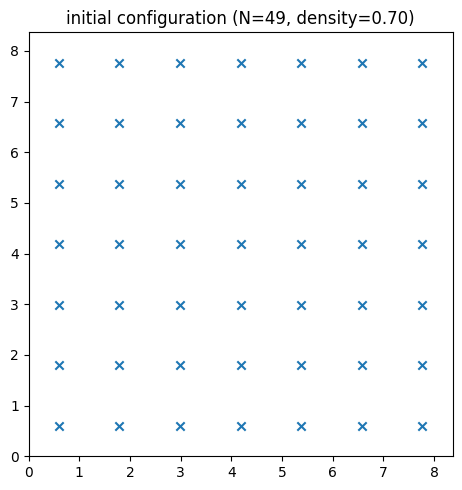

In [ ]:
# plot initial configuration
plt.figure(figsize=(5,5))
plt.title("initial configuration (N={}, density={:.2f})".format(N, rho))
plt.scatter(positions[:,0], positions[:,1], marker='x')
plt.xlim(0, L)
plt.ylim(0, L)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [ ]:
for step in range(n_steps): # n random trial moves

    i = random.randrange(N) # pick a random particle
    old_x, old_y = positions[i].copy() # obtain current position of particle

    # propose random displacement, uniformly chosen
    dx = (random.random() * 2 - 1) * delta
    dy = (random.random() * 2 - 1) * delta

    # apply periodic boundaries
    new_x = (old_x + dx) % L
    new_y = (old_y + dy) % L

    # compute change in energy in moving particle i
    dE = 0.0

    # evaluate how particle intereacts with all other particles
    for j in range(N):
        if j == i: # particle cannot interact with itself
            continue

        # old

        # compute displacement to particle j
        dx_old = old_x - positions[j][0]
        dy_old = old_y - positions[j][1]

        # apply periodic boundary conditions
        dx_old = pbc_dist(dx_old)
        dy_old = pbc_dist(dy_old)

        # compute Lennard-Jones energy contribution
        r2_old = dx_old*dx_old + dy_old*dy_old
        e_old = pair_energy(r2_old)

        # new

        # new distances
        dx_new = new_x - positions[j][0]
        dy_new = new_y - positions[j][1]

        # apply periodic boundary conditions
        dx_new = pbc_dist(dx_new)
        dy_new = pbc_dist(dy_new)

        # compute Lennard-Jones energy contribution
        r2_new = dx_new*dx_new + dy_new*dy_new
        e_new = pair_energy(r2_new)

        # add the energy difference to dE:
        dE += (e_new - e_old)

    attempts += 1 # update counter

    # move results in lower energy, accept automatically
    # otherwie accept with probability exp(−ΔE/kT)
    if dE <= 0.0 or random.random() < math.exp(-dE / kT):
        # move is accepted (if rejected, nothing happens)
        positions[i][0] = new_x
        positions[i][1] = new_y
        E += dE
        accepted += 1

    if step % record_interval == 0: # record once per interval
        energies.append(E / N)  # potential per particle

# compute acceptance ratio
acceptance_ratio = accepted / attempts

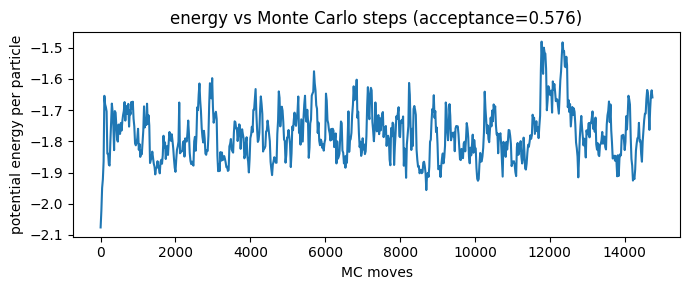

In [ ]:
# plot energy (trace)
plt.figure(figsize=(7,3))
plt.plot(np.arange(len(energies)) * record_interval, energies)
plt.xlabel("MC moves")
plt.ylabel("potential energy per particle")
plt.title("energy vs Monte Carlo steps (acceptance={:.3f})".format(acceptance_ratio))
plt.tight_layout()
plt.show()

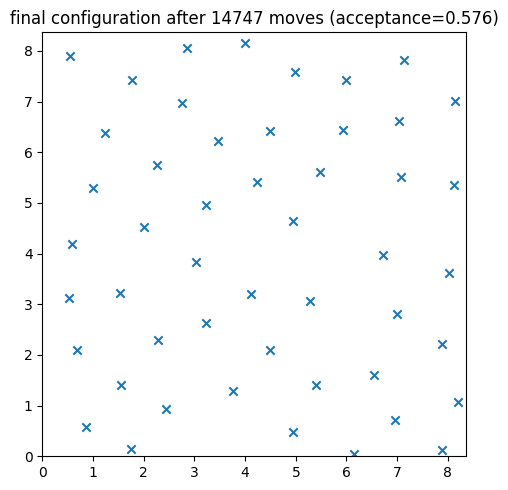

In [ ]:
# plot final config
plt.figure(figsize=(5,5))
plt.title("final configuration after {} moves (acceptance={:.3f})".format(n_steps, acceptance_ratio))
plt.scatter(positions[:,0], positions[:,1], marker='x')
plt.xlim(0, L)
plt.ylim(0, L)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()x
outpath = "metropolis_final_configuration.png"
plt.savefig(outpath)
plt.show()

In [ ]:
# summary of simulation
print("Simulation complete.")
print("box size L = {:.4f}, N = {}, density = {:.4f}".format(L, N, rho))
print("temperature kT = {:.3f}, delta = {:.3f}".format(kT, delta))
print("acceptance ratio = {:.4f}".format(acceptance_ratio))
print("final potential energy per particle = {:.6f}".format(E / N))

Simulation complete.
box size L = 8.3666, N = 49, density = 0.7000
temperature kT = 1.000, delta = 0.150
acceptance ratio = 0.5763
final potential energy per particle = -1.665257
